In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [9]:
!pip install pillow

In [10]:
import pathlib
data_dir = "new_data"
data_dir = pathlib.Path(data_dir)

now have a copy of the dataset available.

In [11]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

2357


thubnail size

In [12]:
size = 128, 128

image data set

In [15]:
actinic_keratosiss = list(data_dir.glob('actinic_keratosis/*'))
basal_cell_carcinomas = list(data_dir.glob('basal_cell_carcinoma/*'))
dermatofibromas = list(data_dir.glob('dermatofibroma/*'))
melanomas = list(data_dir.glob('melanoma/*'))
nevuss = list(data_dir.glob('nevus/*'))
pigmented_benign_keratosiss = list(data_dir.glob('pigmented_benign_keratosis/*'))
seborrheic_keratosiss = list(data_dir.glob('seborrheic_keratosis/*'))
squamous_cell_carcinomas = list(data_dir.glob('squamous_cell_carcinoma/*'))
vascular_lesions = list(data_dir.glob('vascular_lesion/*'))

# Thumbnails from data set

Here are some actinic keratosis:

In [16]:
img = PIL.Image.open(str(actinic_keratosiss[0]))
img.thumbnail(size)
img

PermissionError: [Errno 13] Permission denied: 'new_data\\actinic_keratosis\\.ipynb_checkpoints'

Here are some basal cell carcinoma:

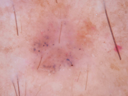

In [17]:
img = PIL.Image.open(str(basal_cell_carcinomas[0]))
img.thumbnail(size)
img

Here are some dermatofibroma:

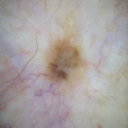

In [18]:
img = PIL.Image.open(str(dermatofibromas[0]))
img.thumbnail(size)
img

Here are some melanoma:

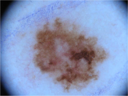

In [19]:
img = PIL.Image.open(str(melanomas[0]))
img.thumbnail(size)
img

Here are some nevus:

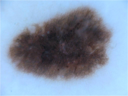

In [20]:
img = PIL.Image.open(str(nevuss[0]))
img.thumbnail(size)
img

Here are some pigmented benign keratosis:

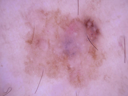

In [21]:
img = PIL.Image.open(str(pigmented_benign_keratosiss[0]))
img.thumbnail(size)
img

Here are some seborrheic keratosis:

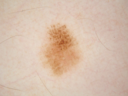

In [22]:
img = PIL.Image.open(str(seborrheic_keratosiss[0]))
img.thumbnail(size)
img

Here are some squamous cell carcinomas:

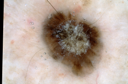

In [23]:
img = PIL.Image.open(str(squamous_cell_carcinomas[0]))
img.thumbnail(size)
img 

And some vascular lesions: 

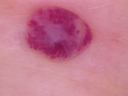

In [24]:
img = PIL.Image.open(str(vascular_lesions[0]))
img.thumbnail(size)
img 


# Load using keras.preprocessing



## Create a dataset

Define some parameters for the loader:

In [25]:
batch_size = 32
img_height = 180
img_width = 180

It's good practice to use a validation split when developing your model. Let's use 80% of the images for training, and 20% for validation.

In [26]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2357 files belonging to 9 classes.
Using 1886 files for training.


In [27]:
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 2357 files belonging to 9 classes.
Using 471 files for validation.


You can find the class names in the `class_names` attribute on these datasets. These correspond to the directory names in alphabetical order.

In [28]:
class_names = train_ds.class_names
print(class_names)

['actinic_keratosis', 'basal_cell_carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented_benign_keratosis', 'seborrheic_keratosis', 'squamous_cell_carcinoma', 'vascular_lesion']


## Visualize the data

Here are the first 9 images from the training dataset.

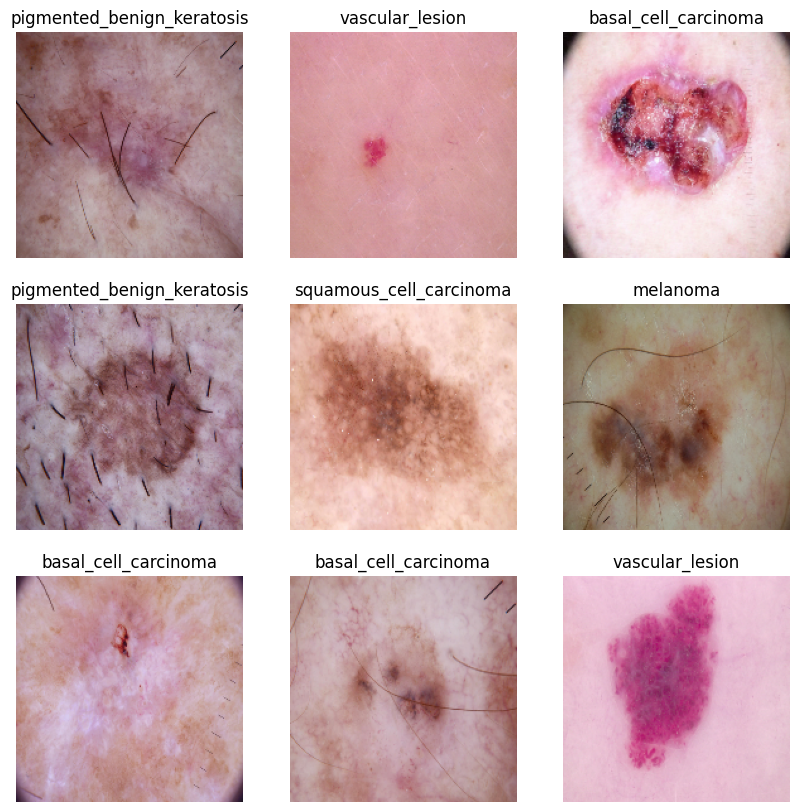

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [30]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(32, 180, 180, 3)
(32,)


## Configure the dataset for performance

Let's make sure to use buffered prefetching so you can yield data from disk without having I/O become blocking. These are two important methods you should use when loading data.

`Dataset.cache()` keeps the images in memory after they're loaded off disk during the first epoch. This will ensure the dataset does not become a bottleneck while training your model. If your dataset is too large to fit into memory, you can also use this method to create a performant on-disk cache.

`Dataset.prefetch()` overlaps data preprocessing and model execution while training. 


In [31]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Standardize the data

The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network; in general you should seek to make your input values small. Here, you will standardize values to be in the `[0, 1]` range by using a Rescaling layer.

In [32]:
normalization_layer = layers.experimental.preprocessing.Rescaling(1./255)

Note: The Keras Preprocessing utilities and layers introduced in this section are currently experimental and may change.

There are two ways to use this layer. You can apply it to the dataset by calling map:

In [33]:
normalized_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
image_batch, labels_batch = next(iter(normalized_ds))
first_image = image_batch[0]
# Notice the pixels values are now in `[0,1]`.
print(np.min(first_image), np.max(first_image)) 

0.023529414 0.8450981


# Create the model

The model consists of three convolution blocks with a max pool layer in each of them. There's a fully connected layer with 128 units on top of it that is activated by a `relu` activation function. This model has not been tuned for high accuracy, the goal of this tutorial is to show a standard approach. 

In [36]:
num_classes = 9

model = Sequential([
  layers.experimental.preprocessing.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

## Compile the model

For this tutorial, choose the `optimizers.Adam` optimizer and `losses.SparseCategoricalCrossentropy` loss function. To view training and validation accuracy for each training epoch, pass the `metrics` argument.

In [37]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

## Model summary

View all the layers of the network using the model's `summary` method:

In [38]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
rescaling_2 (Rescaling)      (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 45, 45, 64)        18496     
_________________________________________________________________
max_pooling2d_5 (MaxPooling2 (None, 22, 22, 64)       

## Train the model

In [40]:
epochs=30
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/30
59/59 [==============================] - 23s 381ms/step - loss: 1.8925 - accuracy: 0.3075 - val_loss: 1.6226 - val_accuracy: 0.3843
Epoch 2/30
59/59 [==============================] - 19s 324ms/step - loss: 1.5468 - accuracy: 0.4735 - val_loss: 1.6529 - val_accuracy: 0.4183
Epoch 3/30
59/59 [==============================] - 18s 299ms/step - loss: 1.3934 - accuracy: 0.5191 - val_loss: 1.3935 - val_accuracy: 0.5159
Epoch 4/30
59/59 [==============================] - 18s 307ms/step - loss: 1.3320 - accuracy: 0.5313 - val_loss: 1.4059 - val_accuracy: 0.5032
Epoch 5/30
59/59 [==============================] - 18s 304ms/step - loss: 1.2131 - accuracy: 0.5748 - val_loss: 1.4194 - val_accuracy: 0.5032
Epoch 6/30
59/59 [==============================] - 18s 302ms/step - loss: 1.1621 - accuracy: 0.5933 - val_loss: 1.4437 - val_accuracy: 0.5202
Epoch 7/30
59/59 [==============================] - 17s 294ms/step - loss: 1.0746 - accuracy: 0.6251 - val_loss: 1.5774 - val_accuracy: 0.5350

## Visualize training results

Create plots of loss and accuracy on the training and validation sets.

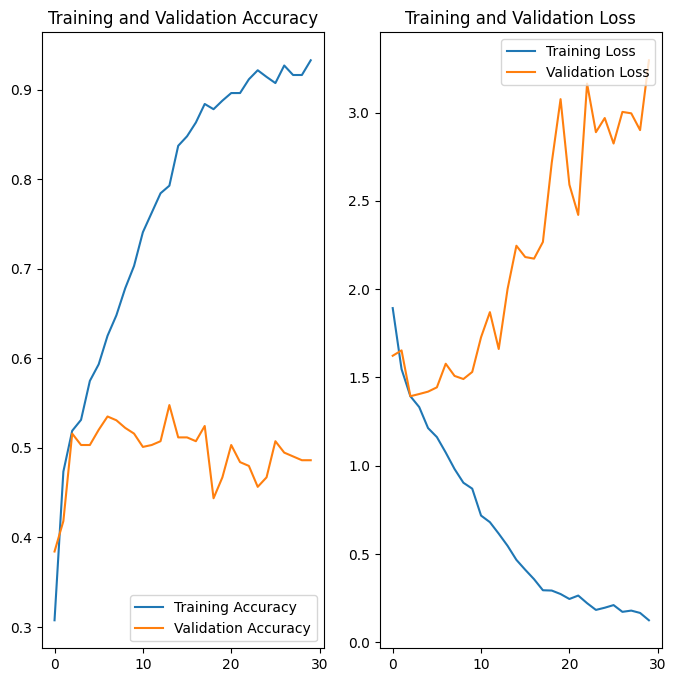

In [41]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

As you can see from the plots, training accuracy and validation accuracy are off by large margin and the model has achieved only around 60% accuracy on the validation set.

Let's look at what went wrong and try to increase the overall performance of the model.

## Overfitting

In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process. Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of [overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit).

When there are a small number of training examples, the model sometimes learns from noises or unwanted details from training examples—to an extent that it negatively impacts the performance of the model on new examples. This phenomenon is known as overfitting. It means that the model will have a difficult time generalizing on a new dataset.

There are multiple ways to fight overfitting in the training process. In this tutorial, you'll use *data augmentation* and add *Dropout* to your model.

## Data augmentation

Overfitting generally occurs when there are a small number of training examples. [Data augmentation](https://www.tensorflow.org/tutorials/images/data_augmentation) takes the approach of generating additional training data from your existing examples by augmenting them using random transformations that yield believable-looking images. This helps expose the model to more aspects of the data and generalize better.

You will implement data augmentation using experimental [Keras Preprocessing Layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/experimental/preprocessing/?version=nightly). These can be included inside your model like other layers, and run on the GPU.

In [42]:
data_augmentation = keras.Sequential(
  [
    layers.experimental.preprocessing.RandomFlip("horizontal", 
                                                 input_shape=(img_height, 
                                                              img_width,
                                                              3)),
    layers.experimental.preprocessing.RandomRotation(0.1),
    layers.experimental.preprocessing.RandomZoom(0.1),
  ]
)

Let's visualize what a few augmented examples look like by applying data augmentation to the same image several times:

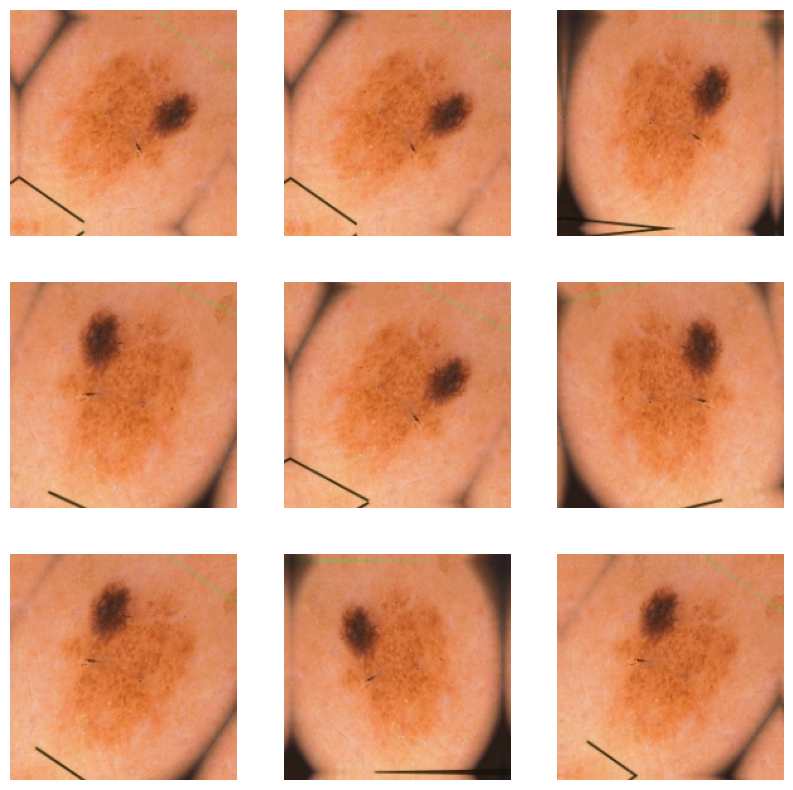

In [43]:
plt.figure(figsize=(10, 10))
for images, _ in train_ds.take(1):
  for i in range(9):
    augmented_images = data_augmentation(images)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_images[0].numpy().astype("uint8"))
    plt.axis("off")

You will use data augmentation to train a model in a moment.

## Dropout

Another technique to reduce overfitting is to introduce [Dropout](https://developers.google.com/machine-learning/glossary#dropout_regularization) to the network, a form of *regularization*.

When you apply Dropout to a layer it randomly drops out (by setting the activation to zero) a number of output units from the layer during the training process. Dropout takes a fractional number as its input value, in the form such as 0.1, 0.2, 0.4, etc. This means dropping out 10%, 20% or 40% of the output units randomly from the applied layer.

Let's create a new neural network using `layers.Dropout`, then train it using augmented images.

In [44]:
model = Sequential([
  data_augmentation,
  layers.experimental.preprocessing.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

## Compile and train the model

In [45]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [46]:
model.summary()

Model: "sequential_3"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
sequential_2 (Sequential)    (None, 180, 180, 3)       0         
_________________________________________________________________
rescaling_3 (Rescaling)      (None, 180, 180, 3)       0         
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 180, 180, 16)      448       
_________________________________________________________________
max_pooling2d_6 (MaxPooling2 (None, 90, 90, 16)        0         
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 90, 90, 32)        4640      
_________________________________________________________________
max_pooling2d_7 (MaxPooling2 (None, 45, 45, 32)        0         
_________________________________________________________________
conv2d_8 (Conv2D)            (None, 45, 45, 64)       

In [47]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
59/59 [==============================] - 25s 409ms/step - loss: 2.2155 - accuracy: 0.1932 - val_loss: 1.8265 - val_accuracy: 0.3439
Epoch 2/15
59/59 [==============================] - 21s 356ms/step - loss: 1.8332 - accuracy: 0.3264 - val_loss: 1.6561 - val_accuracy: 0.4289
Epoch 3/15
59/59 [==============================] - 20s 337ms/step - loss: 1.5936 - accuracy: 0.4166 - val_loss: 1.6355 - val_accuracy: 0.4374
Epoch 4/15
59/59 [==============================] - 20s 341ms/step - loss: 1.5089 - accuracy: 0.4849 - val_loss: 1.7041 - val_accuracy: 0.4374
Epoch 5/15
59/59 [==============================] - 20s 346ms/step - loss: 1.4873 - accuracy: 0.4774 - val_loss: 1.4985 - val_accuracy: 0.5180
Epoch 6/15
59/59 [==============================] - 20s 335ms/step - loss: 1.4667 - accuracy: 0.4797 - val_loss: 1.5194 - val_accuracy: 0.4565
Epoch 7/15
59/59 [==============================] - 21s 358ms/step - loss: 1.3355 - accuracy: 0.5294 - val_loss: 1.4017 - val_accuracy: 0.5265

## Visualize training results

After applying data augmentation and Dropout, there is less overfitting than before, and training and validation accuracy are closer aligned. 

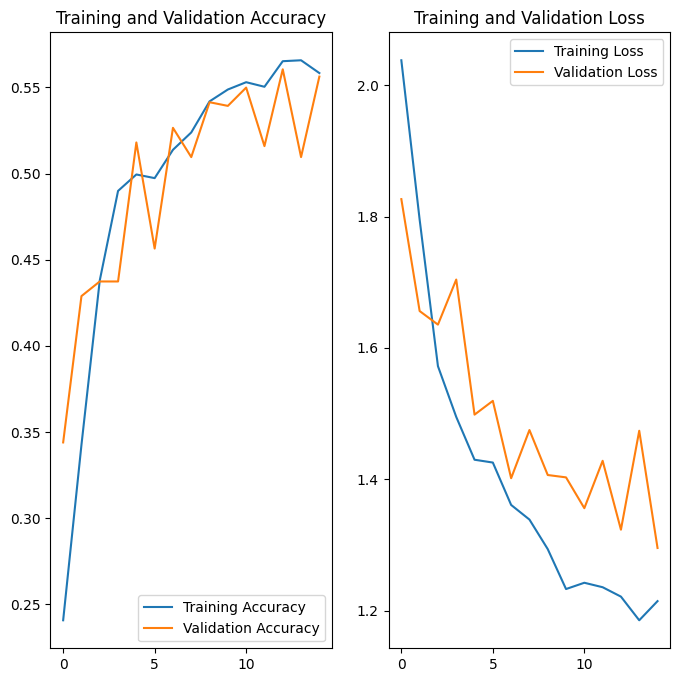

In [51]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Saving Model

In [52]:
model.save_weights('my_checkpoint.ckpt')

## Predict on new data

Note: Data augmentation and Dropout layers are inactive at inference time.

In [53]:
test_image_path = "ISIC_0000002.jpg"

img = keras.preprocessing.image.load_img(
    test_image_path, target_size=(img_height, img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)
PIL.Image.open(test_image_path)

FileNotFoundError: [Errno 2] No such file or directory: 'ISIC_0000002.jpg'

In [ ]:
test_image_path2 = "ISIC_0024454.jpg"

img = keras.preprocessing.image.load_img(
    test_image_path2, target_size=(img_height, img_width)
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)
PIL.Image.open(test_image_path2)